In [1]:
import numpy as np
import pandas as pd

In [2]:
!ls

CarPrice.ipynb
Experiment-Python .ipynb
Homework-regression.ipynb
README.md
Regularization-in-Linear-Regression.ipynb
car_price_data.csv


In [3]:
df=pd.read_csv('car_price_data.csv')

In [4]:
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns=df.columns.str.lower().str.replace(" ","_")

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [8]:
strings=df.dtypes[df.dtypes=='object'].index

In [9]:
strings

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='object')

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_")

In [11]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


## EDA

In [12]:
for col in df.columns:
    print(col)
#     print(df[col].head())
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [13]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


### EDA

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<AxesSubplot:xlabel='msrp', ylabel='Count'>

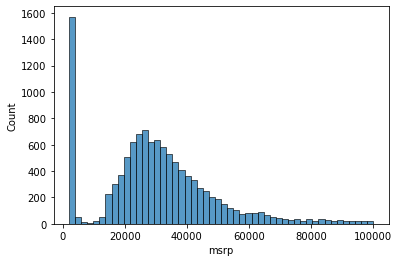

In [15]:
sns.histplot(df.msrp[df.msrp< 100000], bins=50)

In [16]:
price_logs=np.log1p(df.msrp)

In [17]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<AxesSubplot:xlabel='msrp', ylabel='Count'>

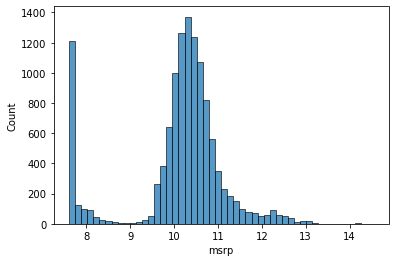

In [18]:
sns.histplot(price_logs, bins=50)

In [19]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [20]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setup thre validation framework

In [21]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=int(n*0.6)

In [22]:
n,n_val+n_test+n_train

(11914, 11912)

### Since counts are differnt we need to fix it

In [23]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test

In [24]:
n,n_val+n_test+n_train

(11914, 11914)

In [25]:
n,n_val,n_test,n_train

(11914, 2382, 2382, 7150)

In [26]:
df_val=df.iloc[:n_val]
df_test=df.iloc[n_val:n_val+n_test]
df_train=df.iloc[n_val+n_test:]

In [27]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4764,ford,flex,2016,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,37800
4765,ford,flex,2017,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,crossover,large,wagon,21,15,5657,43030
4766,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",large,wagon,22,16,5657,40180
4767,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,32730
4768,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,38230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


### Its important to shuffle this dataset, Since its all sequential now so not making any sense.

In [28]:
n,n_val,n_test,n_train

(11914, 2382, 2382, 7150)

In [29]:
df_train=df.iloc[n_train:]
df_val=df.iloc[n_train:n_train+n_val]
df_test=df.iloc[n_train+n_val:]

In [30]:
idx=np.arange(n)

In [31]:
np.random.seed(2)
np.random.shuffle(idx)

In [32]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336])

In [33]:
df_train=df.iloc[idx[n_train:]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]

In [34]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
11798,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
6637,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2575,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [35]:
len(df_train),len(df_val),len(df_test)

(4764, 2382, 2382)

In [36]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [37]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [38]:
y_train=np.log1p(df_train.msrp.values)
y_val=np.log1p(df_val.msrp.values)
y_test=np.log1p(df_test.msrp.values)

In [39]:
del df_train['msrp']
del df_test['msrp']
del df_val['msrp']

### Linear Regression

In [40]:
df_train.iloc[10]

make                                      gmc
model                                  savana
year                                     2014
engine_fuel_type     flex-fuel_(unleaded/e85)
engine_hp                               310.0
engine_cylinders                          8.0
transmission_type                   automatic
driven_wheels                 all_wheel_drive
number_of_doors                           3.0
market_category                     flex_fuel
vehicle_size                          midsize
vehicle_style                   passenger_van
highway_mpg                                17
city_mpg                                   13
popularity                                549
Name: 10, dtype: object

In [41]:
xi=[453,11,86]
w0=7.17
w=[0.01,0.04,0.002]

In [42]:
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range(n):
        pred=pred+w[j]*xi[j]
    return pred

In [43]:
linear_regression(xi)

12.312

In [44]:
np.exp(12.312)-1

222347.2221101062

In [45]:
np.expm1(12.312)

222347.2221101062

In [46]:
np.log1p(222347.2221101062)

12.312

### Linear Regression Vector Form

In [47]:
def dot(xi,w):
    n=len(xi)
    res=0.0
    for j in range(n):
        res=res + xi[j]*w[j]
    return res

In [48]:
def linear_regression(xi):
    return w0+dot(xi,w)

In [49]:
w_new=[w0]+w

In [50]:
def linear_regression(xi):
    xi= [1]+xi
    return dot(xi,w_new)

In [51]:
linear_regression(xi)

12.312

In [52]:
x1=[1,148,24,1385]
x2=[1,138,25,2031]
x3=[1,453,11,85]

In [53]:
X=[x1,x2,x3]

In [54]:
X

[[1, 148, 24, 1385], [1, 138, 25, 2031], [1, 453, 11, 85]]

In [55]:
X=np.array(X)

In [56]:
X

array([[   1,  148,   24, 1385],
       [   1,  138,   25, 2031],
       [   1,  453,   11,   85]])

In [57]:
X.dot(w_new)

array([12.38 , 13.612, 12.31 ])

In [58]:
def linear_regression(X):
    return X.dot(w_new)

In [59]:
linear_regression(X)

array([12.38 , 13.612, 12.31 ])

### Training a Linear Regression Model

In [60]:
def train_linear_regression(X,y):
    return True
    #Do Something

In [61]:
X=[
    [148,24,1385],
    [138,25,2031],
    [453,11,85],
    [148,24,1385],
    [138,25,2031],
    [453,11,85],
    [148,24,1385],
    [138,25,2031],
    [453,11,85],
]
X=np.array(X)

In [62]:
X

array([[ 148,   24, 1385],
       [ 138,   25, 2031],
       [ 453,   11,   85],
       [ 148,   24, 1385],
       [ 138,   25, 2031],
       [ 453,   11,   85],
       [ 148,   24, 1385],
       [ 138,   25, 2031],
       [ 453,   11,   85]])

In [63]:
ones=np.ones(X.shape[0])

In [64]:
list(np.column_stack([ones,X]))

[array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.380e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  85.]),
 array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.380e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  85.]),
 array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.380e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  85.])]

In [65]:
X=np.column_stack([ones,X])

In [66]:
XTX=X.T.dot(X)

In [67]:
XTX

array([[9.0000000e+00, 2.2170000e+03, 1.8000000e+02, 1.0503000e+04],
       [2.2170000e+03, 7.3847100e+05, 3.5955000e+04, 1.5712890e+06],
       [1.8000000e+02, 3.5955000e+04, 3.9660000e+03, 2.5485000e+05],
       [1.0503000e+04, 1.5712890e+06, 2.5485000e+05, 1.8151233e+07]])

In [68]:
XTX_Inv=np.linalg.inv(XTX)

In [69]:
XTX_Inv

array([[-5.47122117e+15,  7.43269860e+12,  1.92707738e+14,
        -1.83251938e+11],
       [ 7.43269860e+12, -1.00973817e+10, -2.61795034e+11,
         2.48949253e+08],
       [ 1.92707738e+14, -2.61795034e+11, -6.78756554e+12,
         6.45451268e+09],
       [-1.83251938e+11,  2.48949253e+08,  6.45451268e+09,
        -6.13780210e+06]])

In [70]:
y=[100,200,150,250,100,200,150,250,120]

In [71]:
w_full=XTX_Inv.dot(X.T).dot(y)

In [72]:
w0=w_full[0]
w=w_full[0:]

In [73]:
w0,w

(1201.4453125,
 array([ 1.20144531e+03, -5.91659546e-01, -4.00396729e+01,  7.76290894e-03]))

In [74]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_Inv=np.linalg.inv(XTX)
    w_full=XTX_Inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [75]:
train_linear_regression(X,y)

LinAlgError: Singular matrix

### Car Price Baseline Model

In [76]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [77]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [78]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

In [79]:
X_train=df_train[base].fillna(0).values

In [80]:
X_train.shape

(4764, 5)

In [81]:
y_train.shape

(4764,)

In [82]:
w0,w=train_linear_regression(X_train,y_train)

In [83]:
w0,w

(7.436112831495095,
 array([ 8.90446858e-03, -9.71331129e-02,  5.00702192e-02, -1.41250202e-02,
        -1.56882174e-05]))

In [84]:
y_pred=w0+X_train.dot(w)

In [85]:
y_pred

array([ 9.79012601, 10.32516359,  9.81882447, ...,  9.94006193,
       10.22748604, 10.19221317])

<AxesSubplot:ylabel='Count'>

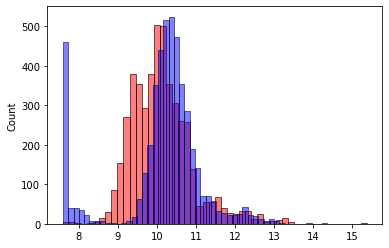

In [86]:
import seaborn as sns
sns.histplot(y_pred, color='red',alpha=0.5,bins=50)
sns.histplot(y_train, color='blue',alpha=0.5,bins=50)

# RMSE

In [87]:
def rmse(y,y_pred):
    error=y-y_pred
    se=error ** 2
    mse=se.mean()
    return np.sqrt(mse)

In [88]:
rmse(y_train,y_pred)

0.7415514275559719

# Validating the Model

In [89]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
# X_train=df_train[base].fillna(0).values
# w0,w=train_linear_regression(X_train,y_train)
# y_pred=w0+X_train.dot(w)

In [90]:
def prepare_X(df):
    df_num=df[base]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

In [91]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)

rmse(y_val,y_pred)

0.7517221959226257

# Feature Engineering

In [92]:
def prepare_X(df):
    df=df.copy()
    df['age']=2017 - df.year
    features=base+['age']
    df_num=df[features]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

In [93]:
# del df_train['age']

In [94]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [95]:
X_train=prepare_X(df_train)
X_train

array([[2.000e+02, 4.000e+00, 2.500e+01, 1.900e+01, 1.385e+03, 2.000e+00],
       [2.410e+02, 4.000e+00, 2.900e+01, 2.200e+01, 6.170e+02, 0.000e+00],
       [1.600e+02, 4.000e+00, 3.600e+01, 2.600e+01, 5.657e+03, 0.000e+00],
       ...,
       [2.500e+02, 6.000e+00, 2.200e+01, 1.500e+01, 1.851e+03, 1.100e+01],
       [1.740e+02, 4.000e+00, 4.200e+01, 3.100e+01, 2.202e+03, 1.000e+00],
       [2.560e+02, 6.000e+00, 2.700e+01, 2.000e+01, 6.400e+02, 2.000e+00]])

In [96]:
w0,w=train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)

rmse(y_val,y_pred)

0.5162117360740259

<AxesSubplot:ylabel='Count'>

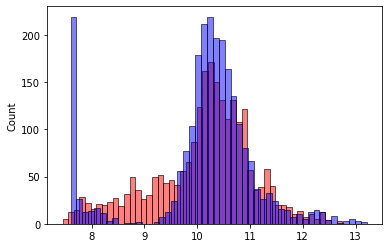

In [97]:
import seaborn as sns
sns.histplot(y_pred, color='red',alpha=0.5,bins=50)
sns.histplot(y_val, color='blue',alpha=0.5,bins=50)

# Categorical Features

In [98]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202


In [99]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [100]:
(df_train.number_of_doors == 4).astype('int')

0       1
1       1
2       1
3       1
4       0
       ..
4759    0
4760    1
4761    1
4762    1
4763    1
Name: number_of_doors, Length: 4764, dtype: int64

In [101]:
df_train['num_doors_4'] = (df_train.number_of_doors == 4).astype('int')
df_train['num_doors_3'] = (df_train.number_of_doors == 3).astype('int')
df_train['num_doors_2'] = (df_train.number_of_doors == 2).astype('int')

In [102]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_4,num_doors_3,num_doors_2
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,1,0,0
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,1,0,0
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,1,0,0
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,1,0,0
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,0,1,0
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,1,0,0
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,1,0,0
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,1,0,0


In [103]:
del df_train['num_doors_4']
del df_train['num_doors_3']
del df_train['num_doors_2']

In [104]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202


In [105]:
def prepare_X(df):
    df=df.copy()
    features=base.copy()
    
    df['age']=2017 - df.year
    features.append('age')
    
    for v in [2,3,4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'num_doors_{v}')

    df_num=df[features]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

In [106]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)

rmse(y_val,y_pred)

51.33631299866555

In [107]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

# Categorical Variables

In [108]:
categorical_variables = ['make','engine_fuel_type','transmission_type','driven_wheels','market_category','vehicle_size','vehicle_style']

In [109]:
makes=list(df.make.value_counts().head().index)

In [110]:
prepare_X(df_train)

array([[200.,   4.,  25., ...,   0.,   0.,   1.],
       [241.,   4.,  29., ...,   0.,   0.,   1.],
       [160.,   4.,  36., ...,   0.,   0.,   1.],
       ...,
       [250.,   6.,  22., ...,   0.,   0.,   1.],
       [174.,   4.,  42., ...,   0.,   0.,   1.],
       [256.,   6.,  27., ...,   0.,   0.,   1.]])

In [111]:
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [112]:
categories={}
for c in categorical_variables:
    categories[c]=list(df[c].value_counts().head().index)

In [113]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [114]:
def prepare_X(df):
    df=df.copy()
    features=base.copy()
    
    df['age']=2017 - df.year
    features.append('age')
    
    for c,values in categories.items():
        for v in values:
            df[f"{c}_{v}"] = (df[c] == v).astype('int')
            
    for v in [2,3,4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'num_doors_{v}')

    df_num=df[features]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

In [115]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)

rmse(y_val,y_pred)

51.33631299866555

# Regularization